adaboost Evaluation
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
f1_score: 0.9722222222222222

Confusion Matrix:
[[40  3]
 [ 1 70]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Cross-Validation Scores: [0.95614035 0.95614035 0.99122807 0.96491228 0.97345133]
Mean CV Score: 0.9683744760130415

Single Model Evaluation
adaboost Accuracy: 0.8947368421052632


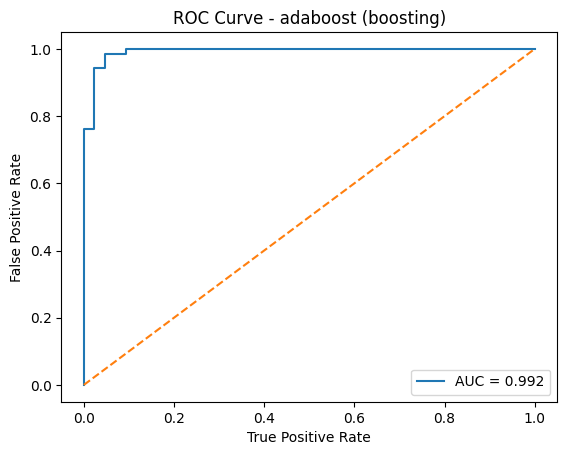

In [9]:
from matplotlib.lines import lineStyles
from numpy import single
# Imports
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

import matplotlib.pyplot as plt

X, y = load_breast_cancer(return_X_y=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

base_model = DecisionTreeClassifier(max_depth=1, random_state=42)

boost_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)
boost_model.fit(X_train, y_train)

y_pred = boost_model.predict(X_test)
y_pred_proba = boost_model.predict_proba(X_test)[:, 1] # Keep probabilities for ROC AUC if needed

print("adaboost Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("f1_score:", f1_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(boost_model, X, y, cv=5, scoring='accuracy')
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())

single_model = DecisionTreeClassifier(max_depth=1, random_state=42)
single_model.fit(X_train, y_train)
single_pred = single_model.predict(X_test)

print("\nSingle Model Evaluation")
print("adaboost Accuracy:", accuracy_score(y_test, single_pred))

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("True Positive Rate")
plt.ylabel("False Positive Rate")
plt.title("ROC Curve - adaboost (boosting)")
plt.legend()
plt.show()